# NHS Trust Demand vs Capacity — Exploratory Analysis

First-pass exploration of the raw A&E activity and HCHS workforce data, before we commit to a cleaning strategy and analytical schema.

**Objectives**

1. Confirm data shape, types, and date coverage
2. Identify which trusts appear in both datasets and which don't (and why)
3. Spot quality issues that need handling in the cleaner
4. Produce a few charts that will become assets for the README


## 1. Setup


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add the repo root to sys.path so we can `import src.load`
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.load import load_ae, load_workforce

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)


In [2]:
RAW_AE = REPO_ROOT / 'data' / 'raw' / 'ae'
RAW_WF = REPO_ROOT / 'data' / 'raw' / 'workforce' / 'trusts-feb-2026' / \
         'Core 1. Staff group - England, NHSE region, ICS and org, Feb-26.csv'

ae = load_ae(RAW_AE)
wf = load_workforce(RAW_WF)

print(f'A&E       : {len(ae):>8,} rows, {ae["month"].nunique()} months, {ae["org_code"].nunique()} orgs')
print(f'Workforce : {len(wf):>8,} rows, {wf["month"].nunique()} months, {wf["org_code"].nunique()} orgs')


/Users/mo/Desktop/Projects/nhs-demand-capacity-dashboard/src/load.py:163: UserWarning: load_ae: dropped 24 rows with unparseable 'Period' (typically totals rows or blank rows in raw NHS files).
  warnings.warn(


A&E       :    4,796 rows, 24 months, 207 orgs
Workforce :  176,717 rows, 29 months, 699 orgs


## 2. A&E activity overview

Two questions: what does the data look like at a single trust, and what does it look like rolled up to England?


In [3]:
ae.head(3)


,month,org_code,org_name,parent_org,total_attendances,total_4hr_breaches,emergency_admissions,dta_waits_4_12h,dta_waits_12plus,four_hour_performance
0,2023-04-01,8J094,BADGER LTD,NHS ENGLAND MIDLANDS,0,0,0,0,0,<NA>
1,2023-05-01,8J094,BADGER LTD,NHS ENGLAND MIDLANDS,0,0,0,0,0,<NA>
2,2023-06-01,8J094,BADGER LTD,NHS ENGLAND MIDLANDS,0,0,0,0,0,<NA>


In [4]:
print('Date range:', ae['month'].min().strftime('%Y-%m'), '→', ae['month'].max().strftime('%Y-%m'))
print('\nRows per month:')
print(ae.groupby('month').size().describe().round(1))
print('\nMissing-value counts:')
print(ae.isna().sum())


Date range: 2023-04 → 2025-03

Rows per month:
count     24.0
mean     199.8
std        2.8
min      197.0
25%      198.0
50%      198.0
75%      203.0
max      204.0
dtype: float64

Missing-value counts:
month                      0
org_code                   0
org_name                   0
parent_org                 0
total_attendances          0
total_4hr_breaches         0
emergency_admissions       0
dta_waits_4_12h            0
dta_waits_12plus           0
four_hour_performance    287
dtype: int64


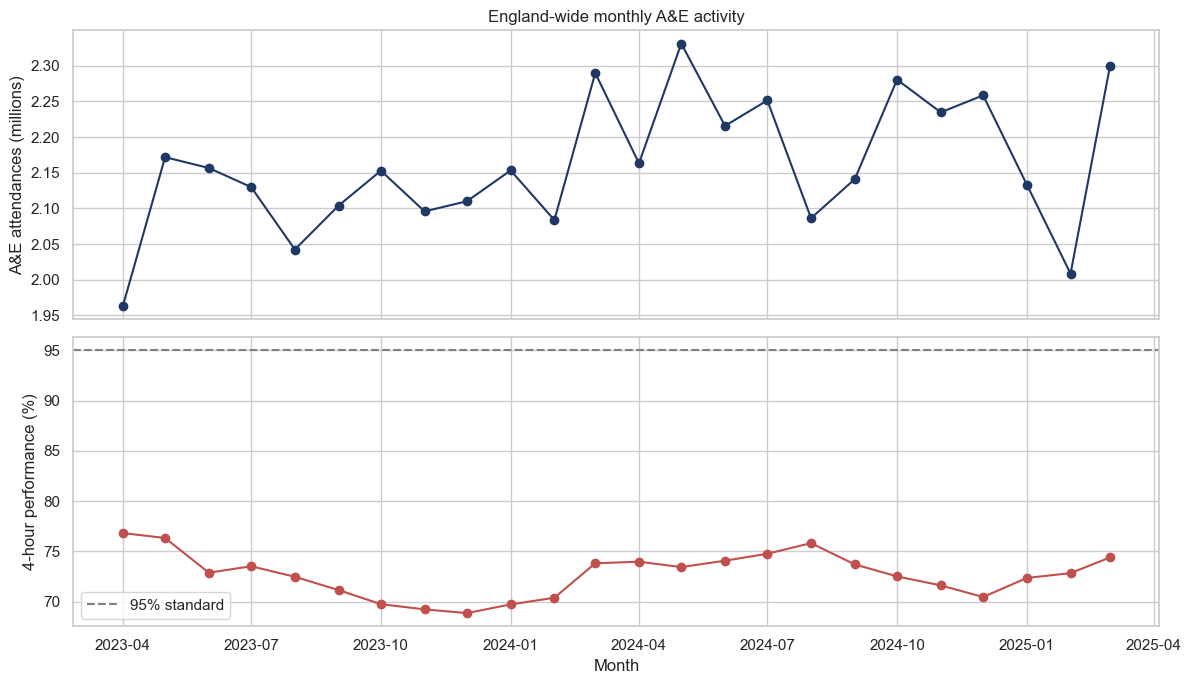

In [5]:
# England-wide monthly totals — seasonal pattern should be clearly visible
england_monthly = ae.groupby('month').agg(
    attendances=('total_attendances', 'sum'),
    breaches=('total_4hr_breaches', 'sum'),
    admissions=('emergency_admissions', 'sum'),
).reset_index()

england_monthly['four_hour_perf'] = 1 - (england_monthly['breaches'] / england_monthly['attendances'])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(england_monthly['month'], england_monthly['attendances'] / 1e6, marker='o', color='#1F3864')
axes[0].set_ylabel('A&E attendances (millions)')
axes[0].set_title('England-wide monthly A&E activity')

axes[1].plot(england_monthly['month'], england_monthly['four_hour_perf'] * 100, marker='o', color='#C0504D')
axes[1].axhline(95, color='gray', linestyle='--', label='95% standard')
axes[1].set_ylabel('4-hour performance (%)')
axes[1].set_xlabel('Month')
axes[1].legend()

plt.tight_layout()
plt.show()


In [6]:
# Top 10 trusts by total A&E activity over the period
top_trusts = (
    ae.groupby(['org_code', 'org_name'])['total_attendances'].sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
top_trusts['attendances_total'] = top_trusts['total_attendances'].apply(lambda x: f'{x:,.0f}')
top_trusts[['org_code', 'org_name', 'attendances_total']]


,org_code,org_name,attendances_total
0,R1H,BARTS HEALTH NHS TRUST,"1,019,837"
1,R0A,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,"935,108"
2,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,"832,881"
3,RAJ,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,"813,383"
4,RM3,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,"789,917"
5,RTG,UNIVERSITY HOSPITALS OF DERBY AND BURTON NHS F...,"711,571"
6,RDU,FRIMLEY HEALTH NHS FOUNDATION TRUST,"703,837"
7,RR8,LEEDS TEACHING HOSPITALS NHS TRUST,"700,796"
8,RYR,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,"680,268"
9,RF4,"BARKING, HAVERING AND REDBRIDGE UNIVERSITY HOS...","673,643"


## 3. Workforce overview

The workforce file is in long format — one row per trust × month × staff group. We'll first look at the top-level totals.


In [7]:
wf.head(3)


,month,org_code,org_name,nhse_region,ics,main_staff_group,staff_group_1,fte,headcount
0,2015-09-01,00C,NHS Darlington CCG,North East and Yorkshire,North East and North Cumbria,All staff groups,All staff groups,1.0,1
1,2015-09-01,00C,NHS Darlington CCG,North East and Yorkshire,North East and North Cumbria,NHS infrastructure support,All staff groups,1.0,1
2,2015-09-01,00C,NHS Darlington CCG,North East and Yorkshire,North East and North Cumbria,NHS infrastructure support,Senior managers,1.0,1


In [8]:
print('Date range:', wf['month'].min().strftime('%Y-%m'), '→', wf['month'].max().strftime('%Y-%m'))
print('\nMain staff groups:')
print(wf['main_staff_group'].value_counts())
print('\nNHS England regions:')
print(wf['nhse_region'].value_counts())


Date range: 2009-09 → 2026-02

Main staff groups:
main_staff_group
Professionally qualified clinical staff    97071
NHS infrastructure support                 43003
Support to clinical staff                  23296
All staff groups                            9135
Unknown classification                      4212
Name: count, dtype: int64

NHS England regions:
nhse_region
Midlands                    34242
London                      27771
North East and Yorkshire    27045
North West                  26574
South East                  23914
East of England             19323
South West                  17848
Name: count, dtype: int64


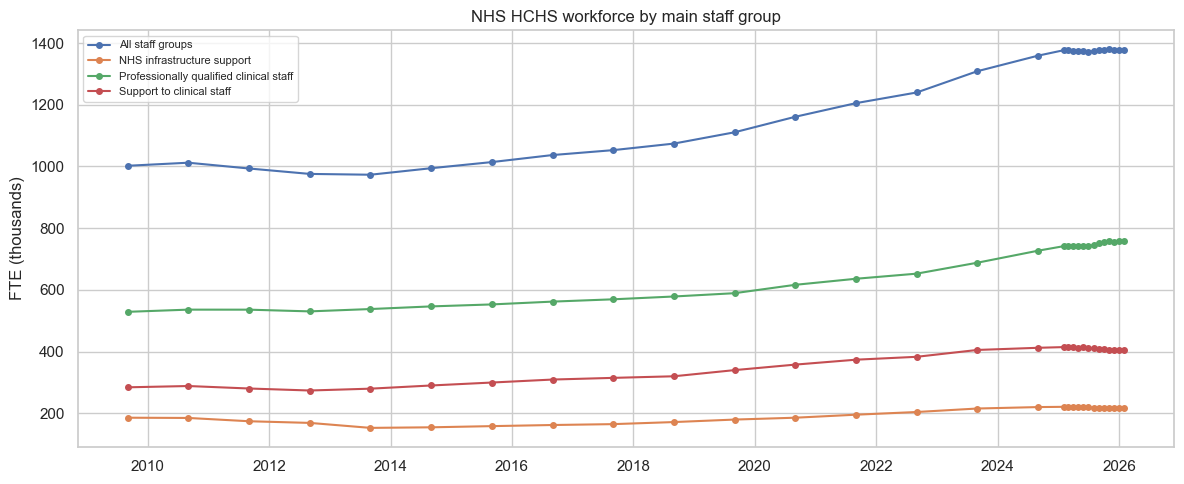

In [9]:
# Total NHS workforce FTE by staff group over time
wf_totals = (
    wf[wf['staff_group_1'] == 'All staff groups']
    .groupby(['month', 'main_staff_group'])['fte'].sum().reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for group, group_data in wf_totals.groupby('main_staff_group'):
    ax.plot(group_data['month'], group_data['fte'] / 1000, marker='o', label=group, markersize=4)
ax.set_ylabel('FTE (thousands)')
ax.set_title('NHS HCHS workforce by main staff group')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


## 4. Joining the datasets — trust overlap

Both files use the same `org_code` scheme. We need to understand:

- How many trusts appear in both files (these are our analytical population)
- Which trusts are A&E-only or workforce-only, and why


In [10]:
ae_orgs = set(ae['org_code'].unique())
wf_orgs = set(wf['org_code'].unique())

both = ae_orgs & wf_orgs
ae_only = ae_orgs - wf_orgs
wf_only = wf_orgs - ae_orgs

print(f'Trusts in both         : {len(both):>4}  ← analytical population')
print(f'Trusts in A&E only     : {len(ae_only):>4}')
print(f'Trusts in workforce only: {len(wf_only):>4}')


Trusts in both         :  153  ← analytical population
Trusts in A&E only     :   54
Trusts in workforce only:  546


In [11]:
# What sort of orgs appear in A&E but not in workforce?
# These are typically walk-in centres, private providers, urgent care centres.
ae_only_sample = (
    ae[ae['org_code'].isin(ae_only)]
    .groupby(['org_code', 'org_name'])['total_attendances'].sum()
    .sort_values(ascending=False)
    .head(15)
)
ae_only_sample.to_frame('total_attendances')


,,total_attendances
org_code,org_name,
NLX,SIRONA CARE & HEALTH,193233
Y02147,URGENT CARE CENTRE (QMS),183788
Y02615,SOUTH BIRMINGHAM GP WALK IN CENTRE,166336
NNJ07,LOUGHBOROUGH URGENT CARE CENTRE,133681
NTPAD,PRACTICE PLUS GROUP SURGICAL CENTRE - ST MARYS PORTSMOUTH,129596
NTP11,PRACTICE PLUS GROUP HOSPITAL - SOUTHAMPTON,127175
NR3,NOTTINGHAM CITYCARE PARTNERSHIP,125380
ACH01,WHITSTABLE MEDICAL PRACTICE,117695
NL7,ASSURA VERTIS URGENT CARE CENTRES (BIRMINGHAM),103751


In [12]:
# Sanity check: at the most recent A&E month, how many of the 153 overlap trusts
# actually have any A&E attendances? Some trusts in the overlap might be mental
# health or community trusts that report zero A&E activity.
latest_month = ae['month'].max()
latest = ae[(ae['month'] == latest_month) & (ae['org_code'].isin(both))]

with_activity = (latest['total_attendances'] > 0).sum()
without = (latest['total_attendances'] == 0).sum()

print(f'Latest month: {latest_month:%Y-%m}')
print(f'  Overlap trusts with A&E attendances: {with_activity}')
print(f'  Overlap trusts with zero A&E attendances: {without}')

# Show the zero-activity ones so we can decide whether to filter them out
zero_activity = (
    latest[latest['total_attendances'] == 0]
    [['org_code', 'org_name', 'emergency_admissions']]
    .head(10)
)
zero_activity


Latest month: 2025-03
  Overlap trusts with A&E attendances: 141
  Overlap trusts with zero A&E attendances: 9


,org_code,org_name,emergency_admissions
1285,RAN,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,27
1488,RBQ,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,170
1560,RBV,THE CHRISTIE NHS FOUNDATION TRUST,821
1848,RDY,DORSET HEALTHCARE UNIVERSITY NHS FOUNDATION TRUST,1
1942,RET,THE WALTON CENTRE NHS FOUNDATION TRUST,182
2398,RJ8,CORNWALL PARTNERSHIP NHS FOUNDATION TRUST,90
2662,RL1,THE ROBERT JONES AND AGNES HUNT ORTHOPAEDIC HO...,0
4129,RXG,SOUTH WEST YORKSHIRE PARTNERSHIP NHS FOUNDATIO...,131
4473,RYG,COVENTRY AND WARWICKSHIRE PARTNERSHIP NHS TRUST,74


## 5. Sample join — does the schema work?

Final check: pick the most recent month in both files and do an inner join to confirm the schema holds.


In [13]:
# Workforce — most recent month, total staff per trust
wf_latest_month = wf['month'].max()
wf_totals_by_trust = (
    wf[(wf['month'] == wf_latest_month) & (wf['staff_group_1'] == 'All staff groups') &
       (wf['main_staff_group'] == 'All staff groups')]
    [['org_code', 'org_name', 'nhse_region', 'fte', 'headcount']]
    .rename(columns={'fte': 'total_fte', 'headcount': 'total_headcount'})
)

# A&E — most recent month, attendances per trust
ae_latest = ae[ae['month'] == latest_month][['org_code', 'total_attendances', 'four_hour_performance']]

# Inner join
merged = ae_latest.merge(wf_totals_by_trust, on='org_code', how='inner')
merged = merged[merged['total_attendances'] > 0].copy()
merged['attendances_per_fte'] = merged['total_attendances'] / merged['total_fte']

print(f'Joined trusts (latest month, with A&E activity): {len(merged)}')
print(f'A&E month:       {latest_month:%Y-%m}')
print(f'Workforce month: {wf_latest_month:%Y-%m}')
merged.sort_values('total_attendances', ascending=False).head(10)


Joined trusts (latest month, with A&E activity): 141
A&E month:       2025-03
Workforce month: 2026-02


,org_code,total_attendances,four_hour_performance,org_name,nhse_region,total_fte,total_headcount,attendances_per_fte
5,R1H,44872,0.708794,Barts Health NHS Trust,London,19719.86027,21365,2.275473
12,RAL,42555,0.74849,Royal Free London NHS Foundation Trust,London,16334.09074,17667,2.605287
0,R0A,40165,0.737458,Manchester University NHS Foundation Trust,North West,27897.42860,30715,1.439738
98,RRK,37090,0.625586,University Hospitals Birmingham NHS Foundation...,Midlands,22939.87177,25896,1.616836
35,RDU,36779,0.730199,Frimley Health NHS Foundation Trust,South East,10535.87305,11598,3.490836
11,RAJ,35753,0.667468,Mid and South Essex NHS Foundation Trust,East of England,14944.71605,16790,2.392351
75,RM3,34714,0.687561,Northern Care Alliance NHS Foundation Trust,North West,18624.66064,20870,1.863873
96,RR8,31514,0.792441,Leeds Teaching Hospitals NHS Trust,North East and Yorkshire,18809.50040,21242,1.675430
41,RF4,31186,0.783877,"Barking, Havering and Redbridge University Hos...",London,8147.45922,8805,3.827696
147,RYR,30200,0.65894,University Hospitals Sussex NHS Foundation Trust,South East,16156.27767,18278,1.869242


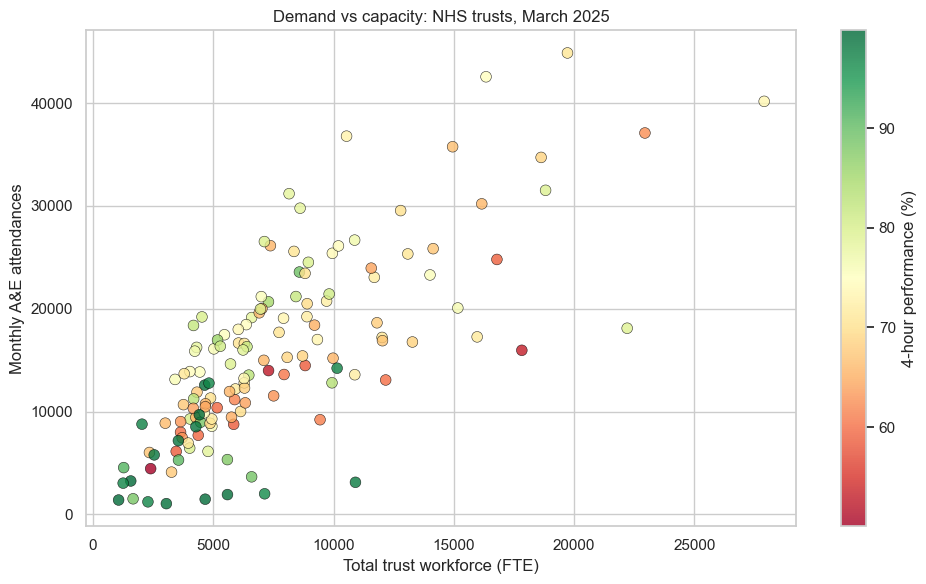

In [14]:
# Quick scatter — workforce vs activity (the demand-vs-capacity question)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(merged['total_fte'], merged['total_attendances'],
           c=merged['four_hour_performance'] * 100, cmap='RdYlGn',
           s=60, edgecolor='black', linewidth=0.4, alpha=0.8)
ax.set_xlabel('Total trust workforce (FTE)')
ax.set_ylabel('Monthly A&E attendances')
ax.set_title(f'Demand vs capacity: NHS trusts, {latest_month:%B %Y}')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('4-hour performance (%)')
plt.tight_layout()
plt.show()


## 6. Findings & decisions for the cleaner

_(Fill in based on what you see above. Expected pattern:)_

- **Analytical population**: ~150 trusts in both files, of which ~130 have meaningful A&E activity at any given month.
- **Filter out**: trusts with zero attendances throughout (mental-health-only and community trusts with no A&E).
- **Filter out**: A&E-only providers (walk-in centres, urgent care centres) — they have no workforce data so can't sit on the demand-vs-capacity chart.
- **Date alignment**: A&E covers 24 months; workforce covers ~29 months at Organisation level — plenty of overlap.
- **Schema confirmed**: clean inner join on `(org_code, month)` works for both the snapshot view and time-series view.

Next step: write `src/clean.py` to produce processed Parquet files for `dim_trust`, `fact_ae_monthly`, and `fact_workforce_monthly`.
